In [3]:
# Plot BIAS CORRECTED OSDMA8: Highest seasonal (6-month) average of 8-hour daily
# maximum ozone concentrations across 15 months (Jan-Mar) for workflow

In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter
from utils.utils import get_scenario_config

In [4]:
def load_OSDMA8_BC_ensemble_members(model, scenario, config):
    # === Path config ===
    OSDMA8_DIR = f"/glade/work/awells/air_quality/{model}/ozone/OSDMA8_BC/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"OSDMA8_BC_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(OSDMA8_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [5]:
def process_osdma8_bc_for_plotting(model, scenario, config):
    # Load ensemble members
    da = load_OSDMA8_BC_ensemble_members(model, scenario, config)

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last year values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [20]:
def plot_osdma8_bc(da, model, scenario, start_year, end_year, SAVE_DIR, land=False):
    # Create figure and layout
    fig = plt.figure(figsize=autosize_figure(1, 1, scale_factor=1.2))
    gs = GridSpec(2, 1, height_ratios=[15, 1])

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    if land is True:
        da = land_filter(da)

    # Plot map
    ax = fig.add_subplot(gs[0, 0], projection=projection)
    cb = da.plot(
        transform=crs,
        add_colorbar=False,
        vmin=-3.5,
        vmax=3.5,
        cmap="RdBu_r",
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Bias Corrected OSDMA8:\n Seasonal average of 8hr daily max\n {model} {scenario} {start_year}-{end_year}", fontsize=14)

    # Colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("Ozone (ppb)", fontsize=13)

    plt.tight_layout()

    if land is True:
        out_file = f"OSDMA8_BC_land_{model}_{scenario}_{start_year}-{end_year}.png"
    else:
        out_file = f"OSDMA8_BC_{model}_{scenario}_{start_year}-{end_year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


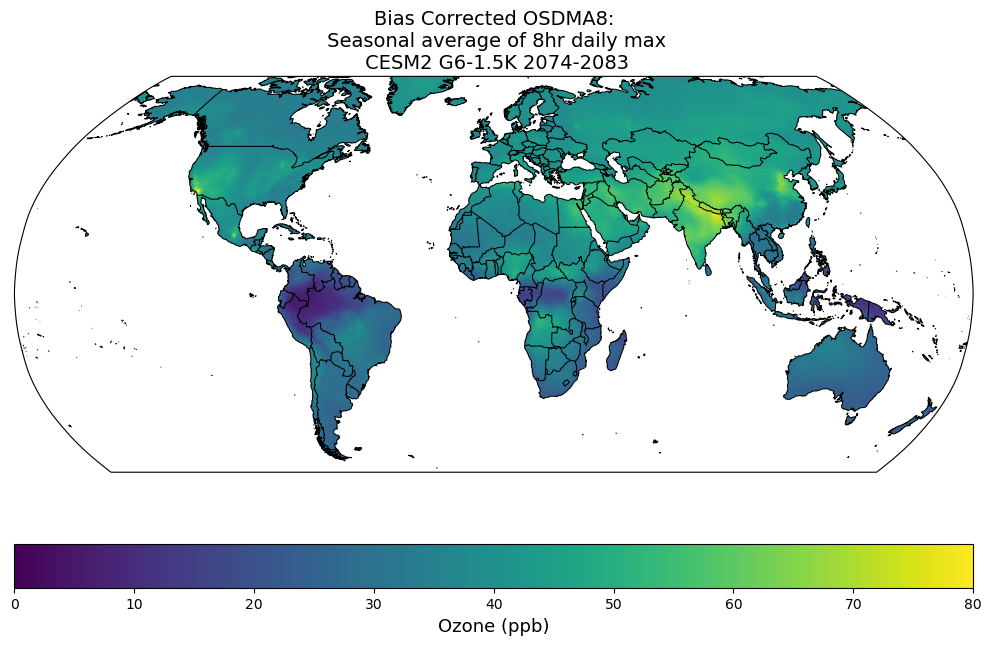

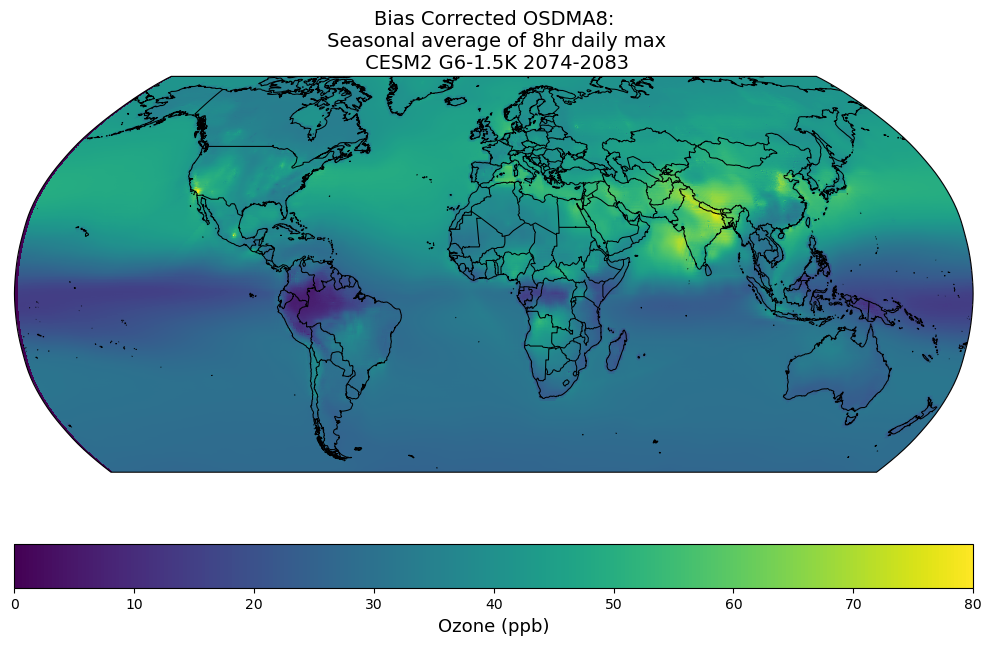

In [14]:
# === Scenario and path config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/ozone/OSDMA8_BC/"

model = "CESM2"
scenario = "G6-1.5K"

config = get_scenario_config(model, scenario)

da, first_year, last_year = process_osdma8_bc_for_plotting(model, scenario, config)

# Plotting without ocean
plot_osdma8_bc(da, model, scenario, first_year, last_year, SAVE_DIR, land=True)
# Plotting with ocean
plot_osdma8_bc(da, model, scenario, first_year, last_year, SAVE_DIR, land=False)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


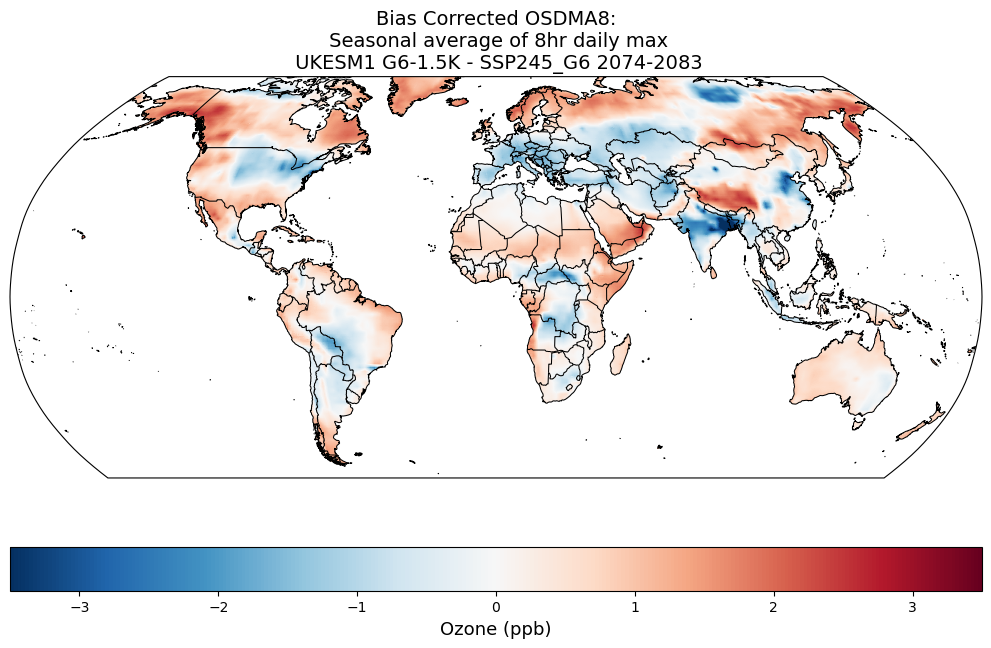

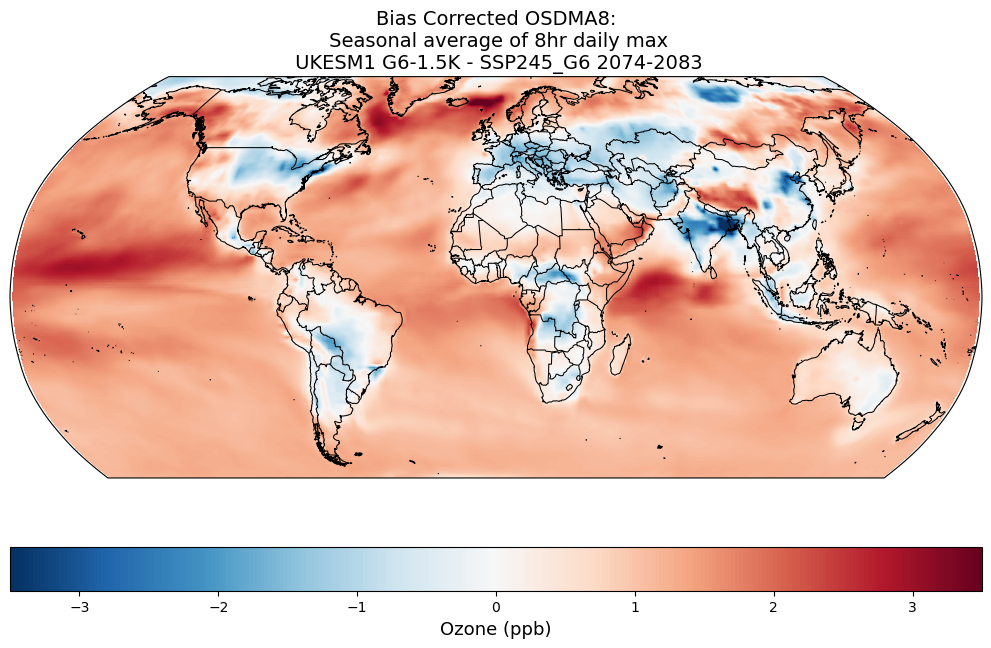

In [22]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised

SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/ozone/OSDMA8_BC/"

model = "UKESM1"
scenario = ["G6-1.5K", "SSP245_G6"]
scenario_name = f"{scenario[0]} - {scenario[1]}"

config1 = get_scenario_config(model, scenario[0])
config2 = get_scenario_config(model, scenario[1])

da1, first_year1, last_year1 = process_osdma8_bc_for_plotting(model, scenario[0], config1)
da2, first_year2, last_year2 = process_osdma8_bc_for_plotting(model, scenario[1], config2)

da = da1 - da2  # Check this is the way round you want it

# Plotting without ocean
plot_osdma8_bc(da, model, scenario_name, first_year1, last_year1, SAVE_DIR, land=True)
# Plotting with ocean
plot_osdma8_bc(da, model, scenario_name, first_year2, last_year2, SAVE_DIR, land=False)